In [6]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

In [7]:
import numpy as np
import scipy as sp
from scipy import linalg

# =====================================================
# USER SETTINGS (Keep as 1-based for readability)
blade_step = 5
support_step = 1

tower_start = 1  
tower_end = 46    
hub_start = 70
hub_end = 72

# =====================================================
# NODE GENERATION (Internal conversion to 0-based)
# =====================================================

def part_nodes(start, end, step):
    """
    Generates nodes based on 1-based input, 
    but returns 0-based indices for Python.
    """
    nodes = list(np.arange(start, end + 1, step))
    
    if nodes[-1] != end:
        nodes.append(end)
    if nodes[0] != start:
        nodes.insert(0, start)
    
    return np.unique(np.array(nodes)) - 1

# Generate Dynamic Node Lists
support_nodes = part_nodes(tower_start, tower_end, support_step)
hub_nodes     = [70-1, 72-1]  # Explicitly include all hub nodes
blade1_nodes  = part_nodes(73, 141, blade_step)
blade2_nodes  = part_nodes(142, 210, blade_step)
blade3_nodes  = part_nodes(211, 279, blade_step)

# Combine all dynamic nodes and add specific ones (19 and 23 in 1-based)
dynamic_nodes = np.unique(np.concatenate([
    support_nodes,
    hub_nodes,
    blade1_nodes,
    blade2_nodes,
    blade3_nodes,
    [19 - 1, 23 - 1]  
]))

# =====================================================
# LOAD FULL MODEL & DEFINE SIZES
# =====================================================
# Load your data (Assuming file exists in path)
data = np.load('owt_XKM.npz')
K_full = data['K']
M_full = data['M']

n_phys_nodes = K_full.shape[0]/6  # Each node has 6 DOFs
n_phys_dofs = K_full.shape[0] # Dynamic way to get 1674

print(f"--- Reduction Settings ---")
print(f"Dynamic Nodes Count: {len(dynamic_nodes)}")
print(f"Dynamic DOFs Count: {len(dynamic_nodes)*6}")

# =====================================================
# SYSTEM REDUCTION (Guyan Reduction)
# =====================================================

# 1. Create Index Sets
block = np.arange(0, 6)
# dynamic_nodes is 0-based, so (0*6)+1 = DOF 1. Correct.
Id_matrix = (dynamic_nodes[:, None]) * 6 + block 
Id = Id_matrix.ravel()  

All_DOFs = np.arange(0, n_phys_dofs)
Is = np.setdiff1d(All_DOFs, Id) 

# 2. Partition Matrices
Kdd, Kds = K_full[np.ix_(Id, Id)], K_full[np.ix_(Id, Is)]
Ksd, Kss = K_full[np.ix_(Is, Id)], K_full[np.ix_(Is, Is)]

Mdd, Mds = M_full[np.ix_(Id, Id)], M_full[np.ix_(Id, Is)]
Msd, Mss = M_full[np.ix_(Is, Id)], M_full[np.ix_(Is, Is)]

# 3. Calculate Transformation Matrix S
S = -np.linalg.solve(Kss, Ksd)

# 4. Calculate Reduced Matrices
K_red = Kdd + Kds @ S
M_red = Mdd + Mds @ S + S.T @ (Msd + Mss @ S)

print(f"Reduced K shape: {K_red.shape}")

# =====================================================
# MODAL ANALYSIS
# =====================================================
n_modes_needed = 20
lam, U_red = sp.linalg.eigh(K_red, M_red, subset_by_index=[0, n_modes_needed-1])

omega = np.sqrt(np.real(lam))
freq = omega / (2 * np.pi)

# Sorting
iw = np.argsort(freq)
freq = freq[iw]
U_red = U_red[:, iw]

# Normalize U_red: Set the maximum displacement in each mode to 1.0
U_norm = U_red / np.max(np.abs(U_red), axis=0)

print(f"Mode 2 Freq: {freq[1]:.4f} Hz")
print(f"Mode 13 Freq: {freq[12]:.4f} Hz")

--- Reduction Settings ---
Dynamic Nodes Count: 93
Dynamic DOFs Count: 558
Reduced K shape: (558, 558)
Mode 2 Freq: 0.1856 Hz
Mode 13 Freq: 1.4604 Hz


In [8]:
# Connectivity vector for viscous damper (Exercise 9/11)
d = 8  # lever arm in meters

# Global DOFs (Hardcoded to match Equation 5 in the PDF)
dof_node19 = 19*6 - 2  
dof_node23 = 23*6 - 2

w = np.zeros((K_red.shape[0], 1))

# Search in the 1-based Id array
if dof_node19 in Id:
    idx_19 = np.where(Id == dof_node19)[0][0]
    w[idx_19, 0] = -d
else:
    print(f"Warning: DOF {dof_node19} not found in Reduced Model!")

if dof_node23 in Id:
    idx_23 = np.where(Id == dof_node23)[0][0]
    w[idx_23, 0] = d
else:
    print(f"Warning: DOF {dof_node23} not found in Reduced Model!")


C:\Users\simon\AppData\Local\Temp\ipykernel_33576\1928928185.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


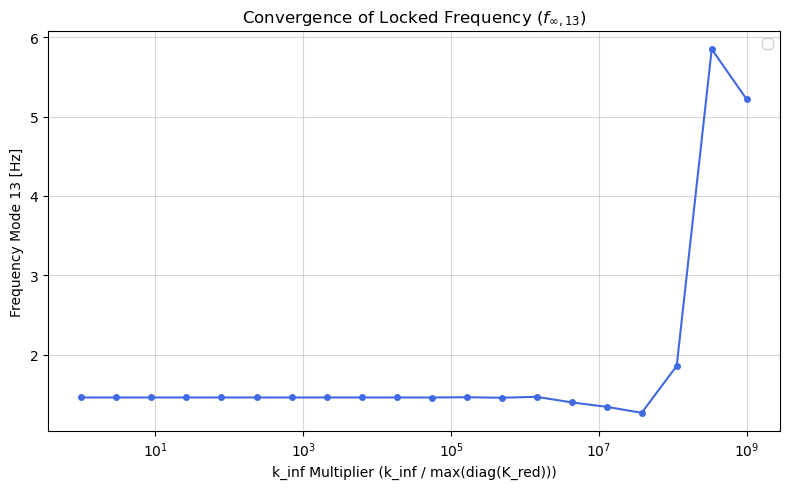

In [9]:
import matplotlib.pyplot as plt

# 1. Define the range of multipliers for k_inf (Logarithmic scale)
multipliers = np.logspace(0, 9, num=20) 
freq_results = []

max_stiff = np.max(np.diag(K_red))

# 2. Loop through multipliers
for m in multipliers:
    # Calculate K_inf for this specific multiplier
    k_test = m * max_stiff
    K_test = K_red + k_test * (w @ w.T)
    
    # Solve for eigenvalues (we only need the first 13 modes)
    # Using subset_by_index to keep it fast
    lam_t, _ = sp.linalg.eigh(K_test, M_red, subset_by_index=[12, 12]) 
    
    # Convert to Hz
    f_t = np.sqrt(np.real(lam_t[0])) / (2 * np.pi)
    freq_results.append(f_t)

# 3. Plotting
plt.figure(figsize=(8, 5))
plt.semilogx(multipliers, freq_results, '-o', color='royalblue', markersize=4)


plt.title('Convergence of Locked Frequency ($f_{\infty, 13}$)')
plt.xlabel('k_inf Multiplier (k_inf / max(diag(K_red)))')
plt.ylabel('Frequency Mode 13 [Hz]')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# EXERCISE 9(a): Locked natural frequency

# 1. Use the REDUCED stiffness matrix to find the reference stiffness
# Using K_red because w and the eigenvalue problem are now in reduced space
max_stiffness = np.max(np.diag(K_red))

# 2. Set k_inf (the "stiff" spring to simulate a lock)
k_inf = 1e4 * max_stiffness 

# 3. Modified stiffness matrix: K_inf = K_red + k_inf * (w @ w.T)
# This adds a very stiff spring across the DOFs defined in w
K_inf = K_red + k_inf * (w @ w.T)

# 4. Solve the modified eigenvalue problem
# Using M_red to match the reduced system size
lam_locked, U_locked = sp.linalg.eigh(K_inf, M_red, subset_by_index=[0, n_modes_needed - 1])

# 5. Process results
lam_locked = np.real(lam_locked)
omega_locked = np.sqrt(lam_locked)
iw_locked = np.argsort(omega_locked)

omega_locked = omega_locked[iw_locked]
freq_locked = omega_locked / (2 * np.pi)
U_locked = U_locked[:, iw_locked]

# 6. Extract Mode 13 (Index 12)
omega_inf_13 = omega_locked[12]
freq_inf_13 = freq_locked[12]
u_inf_13 = U_locked[:, 12]

print(f"\n=== EXERCISE 9(a) ===")
print(f"k_inf = {k_inf:.3e}")
print(f"ω_inf,13 (locked frequency) = {omega_inf_13:.4f} rad/s")
print(f"f_inf,13 (locked frequency) = {freq_inf_13:.4f} Hz")
print(f"omega_inf - omega_13 = {omega_inf_13 - omega[12]:.4f} rad/s")
print(f"freq_inf_13 - freq_13 = {freq_inf_13 - freq[12]:.4f} Hz")


=== EXERCISE 9(a) ===
k_inf = 1.235e+17
ω_inf,13 (locked frequency) = 9.1756 rad/s
f_inf,13 (locked frequency) = 1.4603 Hz
omega_inf - omega_13 = -0.0003 rad/s
freq_inf_13 - freq_13 = -0.0001 Hz


In [11]:
# EXERCISE 9(b): Normalize mode shape to unit modal mass

# 1. Get the un-locked mode 13 (from the original reduced eigenproblem)
u_13 = U_norm[:, 12]

# 2. Calculate modal mass for mode 13 specifically
# CRITICAL FIX: Use M_red to match the size of u_13 (e.g., 450x450, not 1674x1674)
m_13 = u_13.T @ M_red @ u_13

# 3. Normalize to unit modal mass
# Scaling the vector so that u_norm^T * M * u_norm = 1
u_13_norm = u_13 / np.sqrt(m_13)

print(u_13_norm.T @ M_red @ u_13_norm)  # Should be close to 1.0

# 4. Calculate modal amplitude at damper location
# w.flatten() @ u_13_norm gives the relative displacement/rotation seen by the damper
u_13_modal = np.dot(w.flatten(), u_13_norm)

print(f"\n=== EXERCISE 9(b) ===")
print(f"Modal amplitude at damper location (u_13_modal) = {u_13_modal:.4e}")

0.9999999999999996

=== EXERCISE 9(b) ===
Modal amplitude at damper location (u_13_modal) = 3.2203e-07


In [12]:
u_inf = U_locked[:, 12]

# 1. Check and force mass-normalization for the locked mode
m_13 = u_13_norm.T @ M_red @ u_13_norm
m_inf = u_inf.T @ M_red @ u_inf

print(f"Modal mass of u_13_norm: {m_13:.4f} kg")
print(f"Modal mass of u_inf: {m_inf:.4f} kg")

# 2. Re-calculate kappa using the normalized vector
kappa = u_inf.T @ M_red @ u_13_norm
print(f"kappa: {kappa:.4f}")

print(f"1 - kappa: {1 - kappa:.4f}")

Modal mass of u_13_norm: 1.0000 kg
Modal mass of u_inf: 1.0000 kg
kappa: 1.0000
1 - kappa: 0.0000


In [13]:
omega_13 = omega[12]

eta = 1
c_opt = 2*(omega_inf_13 - omega_13) / u_13_modal
print(f"Optimal damping coefficient c_opt = {c_opt:.4f} Ns/m")

zeta_max = (omega_inf_13 - omega_13)/(omega_inf_13 + omega_13)
print(f"Maximum damping ratio zeta_max = {zeta_max:.8f}")

Optimal damping coefficient c_opt = -2076.4016 Ns/m
Maximum damping ratio zeta_max = -0.00001822


In [14]:
np.load('vibprop_sysred_vis.npz')

NpzFile 'vibprop_sysred_vis.npz' with keys: w, c_opt, kappa, zeta_max, omega_13...